# Exploratory Data Analysis (EDA) - OpsPulse

## Project Overview

**OpsPulse** is an end-to-end data analytics project that collects hourly weather forecast data for 20 major Indian cities using the Open-Meteo API. The raw JSON data is processed through a modular ETL pipeline built with Python and Pandas, resulting in a cleaned and feature-engineered dataset for analysis.

This notebook focuses on **Exploratory Data Analysis (EDA)** to uncover meaningful insights, identify trends, understand relationships between weather variables, and compare weather patterns across different cities.

---

## Objectives

The primary objectives of this analysis are to:

- Analyze temperature, humidity, precipitation, wind speed, cloud cover, and atmospheric pressure across cities.
- Compare weather characteristics between different Indian cities.
- Study hourly temperature trends throughout the day.
- Identify cities with the highest and lowest weather metrics.
- Examine correlations between major weather variables.
- Explore the distribution of weather conditions and temperature variation.
- Generate meaningful visualizations to support data-driven insights.

---

## Dataset Information

- **Data Source:** Open-Meteo Weather API
- **Geographical Coverage:** 20 Major Indian Cities
- **Forecast Frequency:** Hourly
- **Forecast Duration:** 7 Days
- **Total Records:** 3,360
- **Features:** 16

### Available Features

- City
- Date
- Time
- Hour
- Day of Week
- Month
- Weekend Indicator
- Temperature (°C)
- Relative Humidity (%)
- Cloud Cover (%)
- Atmospheric Pressure (hPa)
- Wind Speed (km/h)
- Wind Direction (°)
- Precipitation (mm)
- Weather Code
- Day/Night Indicator

---

## Data Processing Pipeline

The dataset used in this notebook was generated through the following pipeline:

1. Extract hourly weather data from the Open-Meteo API.
2. Store raw responses as JSON files.
3. Transform and clean the raw data using Pandas.
4. Perform feature engineering by creating additional temporal attributes.
5. Validate the pipeline using automated Pytest test cases.
6. Export the final processed dataset for analysis.

---

## Tools & Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

---

## Key Business Questions

This notebook aims to answer the following questions:

- Which city has the highest average temperature?
- Which city records the highest humidity?
- Which city experiences the strongest winds?
- Which city receives the highest precipitation?
- Which city has the greatest temperature variation?
- How does temperature change throughout the day?
- How do weather conditions vary across cities?
- What relationships exist between different weather variables?
- Do weather patterns differ between weekdays and weekends?

In [ ]:
# Imports

import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns

In [ ]:
# Load the Dataset

cities_df = pd.read_csv(r"C:\Users\daksh_769tz6y\Desktop\OpsPulse\data\processed\weather_processed.csv")

print("Shape:", cities_df.shape)
print("Columns:", cities_df.columns)
print("Data Types:", cities_df.dtypes)
print("Head:", cities_df.head())
print("Info:", cities_df.info)

Shape: (3360, 16)
Columns: Index(['city', 'time', 'date', 'hour', 'day_of_week', 'month', 'is_weekend',
       'temperature_2m', 'relative_humidity_2m', 'precipitation',
       'cloud_cover', 'pressure_msl', 'wind_speed_10m', 'wind_direction_10m',
       'weather_code', 'is_day'],
      dtype='object')
Data Types: city                     object
time                     object
date                     object
hour                      int64
day_of_week              object
month                     int64
is_weekend                 bool
temperature_2m          float64
relative_humidity_2m      int64
precipitation           float64
cloud_cover               int64
pressure_msl            float64
wind_speed_10m          float64
wind_direction_10m        int64
weather_code              int64
is_day                    int64
dtype: object
Head:         city                 time        date  hour day_of_week  month  \
0  ahemdabad  2026-07-02 00:00:00  2026-07-02     0    Thursday      7   
1  a

**1. Which city has the highest average temperature?**

In [4]:
avg_temp_by_city = (cities_df.groupby("city")["temperature_2m"].mean().sort_values(ascending=False).rename("avg_temperature"))
print(f"Highest Average Temperature City: {avg_temp_by_city.idxmax()}")
print(f"Average Temperature of {avg_temp_by_city.idxmax()} is: {avg_temp_by_city.max():.2f} °C")
print(f"Top 5 Hottest Cities are: {avg_temp_by_city.head()}")

Highest Average Temperature City: chennai
Average Temperature of chennai is: 32.55 °C
Top 5 Hottest Cities are: city
chennai      32.548214
delhi        31.385119
lucknow      30.142857
ahemdabad    29.835714
patna        29.810714
Name: avg_temperature, dtype: float64


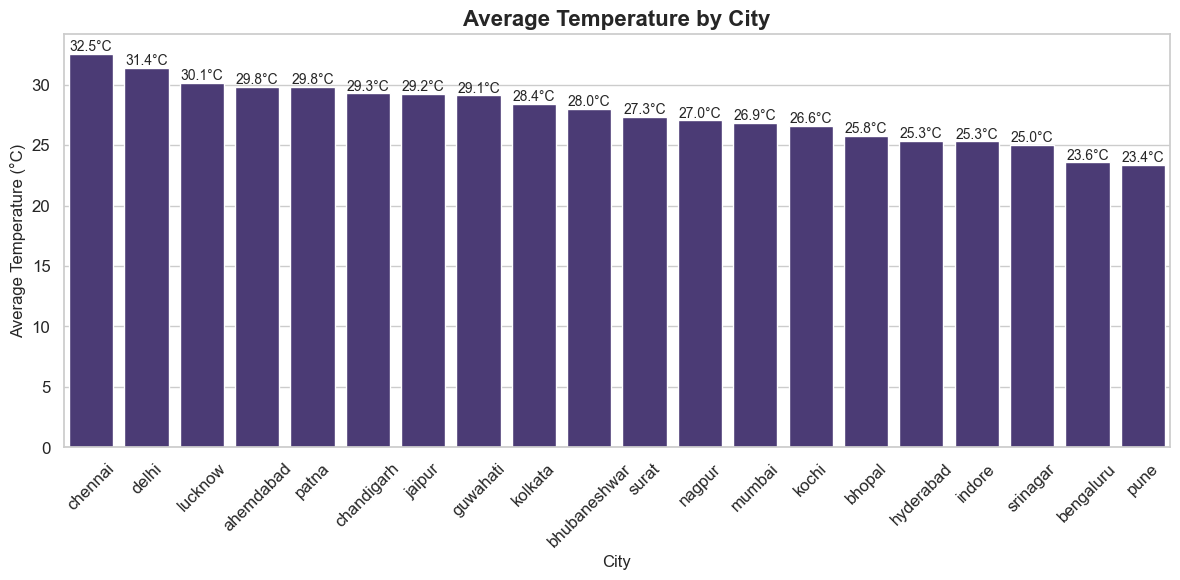

In [5]:
sns.set_theme(
    style="whitegrid",
    palette="viridis",
    font_scale=1.1
)

# Convert Series to DataFrame
temperature_df = avg_temp_by_city.reset_index()

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=temperature_df,
    x="city",
    y="avg_temperature"
)

ax.bar_label(ax.containers[0], fmt='%.1f°C', padding=0, fontsize=10)

plt.title("Average Temperature by City", fontsize=16, fontweight="bold")
plt.xlabel("City", fontsize=12)
plt.ylabel("Average Temperature (°C)", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Insight

- **Chennai** recorded the **highest average temperature** among the 20 Indian cities, with an average of **32.5°C** during the forecast period.
- The **top five hottest cities** were **Chennai, Delhi, Lucknow, Ahmedabad, and Patna**, each maintaining an average temperature above **29.8°C**.
- The **coolest cities** in the dataset were **Pune (23.4°C)** and **Bengaluru (23.6°C)**, indicating comparatively milder weather conditions.
- The difference between the warmest and coolest city averages was approximately **9.1°C**, highlighting noticeable regional variation in weather across India during the forecast period.
- These observations demonstrate how geographical location and regional climate influence average temperature patterns, with some cities consistently experiencing warmer conditions than others.

**2. Which city has the lowest average temperature?**

In [6]:
print(f"Lowest Average Temperature City: {avg_temp_by_city.idxmin()}")
print(f"Average Temperature of {avg_temp_by_city.idxmin()} is: {avg_temp_by_city.min():.2f} °C")

Lowest Average Temperature City: pune
Average Temperature of pune is: 23.38 °C


**3. Which city has the highest humidity?**

In [7]:
humidity_by_city = (cities_df.groupby("city")["relative_humidity_2m"].max().sort_values(ascending=False).rename("max_humidity"))
print(f"Highest Humidity City: {humidity_by_city.idxmax()}")
print(f"Highest Humidity of {humidity_by_city.idxmax()} is: {humidity_by_city.max()} %")
print(f"Top 5 Humid Cities are: {humidity_by_city.head()}")

Highest Humidity City: bhopal
Highest Humidity of bhopal is: 100 %
Top 5 Humid Cities are: city
bhopal      100
surat       100
srinagar    100
guwahati    100
kochi        99
Name: max_humidity, dtype: int64


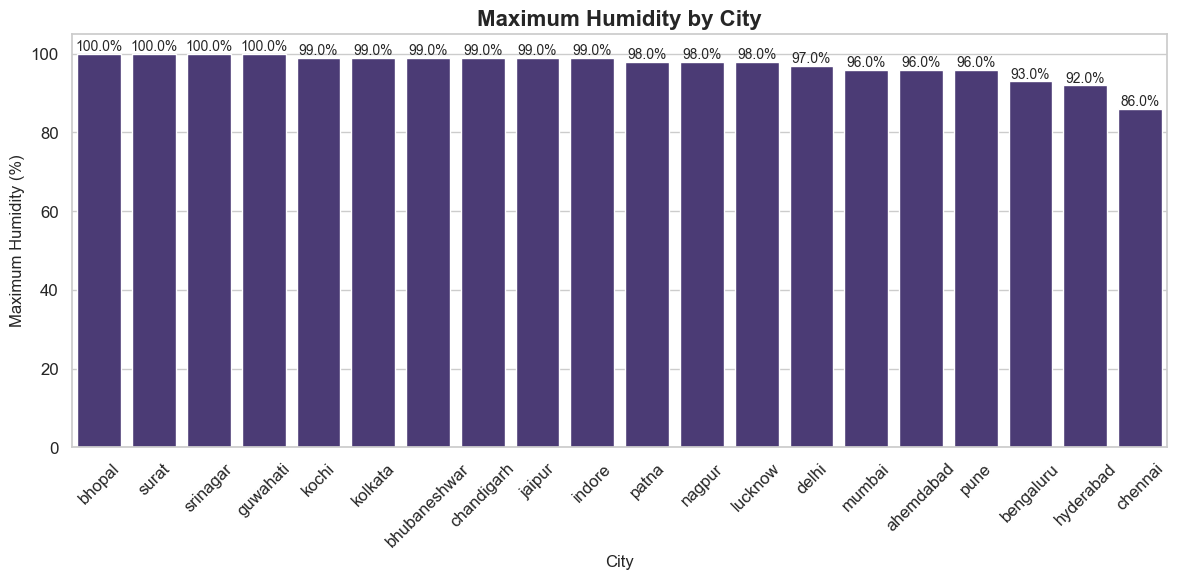

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    palette="viridis",
    font_scale=1.1
)

# Convert Series to DataFrame
humidity_df = humidity_by_city.reset_index()

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=humidity_df,
    x="city",
    y="max_humidity"
)

ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=0, fontsize=10)

plt.title("Maximum Humidity by City", fontsize=16, fontweight="bold")
plt.xlabel("City", fontsize=12)
plt.ylabel("Maximum Humidity (%)", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Insight

- **Bhopal, Surat, Srinagar, and Guwahati** recorded the **highest maximum humidity**, each reaching **100%** during the forecast period.
- Most cities experienced peak humidity values between **96% and 100%**, indicating that high humidity conditions were common across the selected Indian cities.
- **Chennai** recorded the **lowest maximum humidity** at **86%**, followed by **Hyderabad (92%)** and **Bengaluru (93%)**, suggesting comparatively drier atmospheric conditions.
- The difference between the highest and lowest recorded maximum humidity was **14 percentage points (100% vs. 86%)**, reflecting moderate regional variation in peak humidity levels.
- The widespread occurrence of very high maximum humidity values suggests that many cities experienced periods of saturated or near-saturated air, which can contribute to discomfort and increase the likelihood of fog, mist, or precipitation.

**4. Which city experiences the highest wind speed?**

In [9]:
max_wind_speed_by_city = (cities_df.groupby("city")["wind_speed_10m"].max().sort_values(ascending=False).rename("max_windspeed"))
print(f"Highest Wind Speed City: {max_wind_speed_by_city.idxmax()}")
print(f"Highest Wind Speed of {max_wind_speed_by_city.idxmax()} is: {max_wind_speed_by_city.max()} kmph")
print(f"Top 5 Cities With Highest Wind Speed are: {max_wind_speed_by_city.head()}")

Highest Wind Speed City: hyderabad
Highest Wind Speed of hyderabad is: 35.3 kmph
Top 5 Cities With Highest Wind Speed are: city
hyderabad    35.3
mumbai       31.0
indore       30.5
bengaluru    30.1
pune         28.2
Name: max_windspeed, dtype: float64


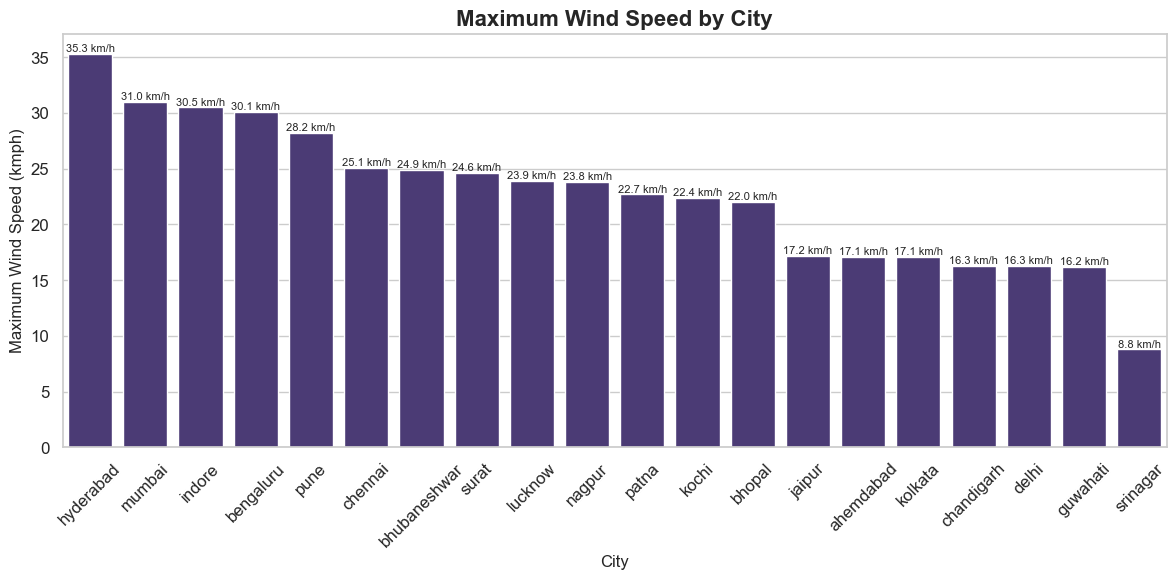

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    palette="viridis",
    font_scale=1.1
)

# Convert Series to DataFrame
windspeed_df = max_wind_speed_by_city.reset_index()

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=windspeed_df,
    x="city",
    y="max_windspeed"
)

ax.bar_label(ax.containers[0], fmt='%.1f km/h', padding=0, fontsize=8)

plt.title("Maximum Wind Speed by City", fontsize=16, fontweight="bold")
plt.xlabel("City", fontsize=12)
plt.ylabel("Maximum Wind Speed (kmph)", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Insight

- **Hyderabad** recorded the **highest maximum wind speed** among the 20 cities, reaching **35.3 km/h**, indicating the strongest wind conditions during the forecast period.
- The **top five cities** with the highest recorded wind speeds were **Hyderabad (35.3 km/h)**, **Mumbai (31.0 km/h)**, **Indore (30.5 km/h)**, **Bengaluru (30.1 km/h)**, and **Pune (28.2 km/h)**.
- **Srinagar** experienced the **lowest maximum wind speed** at **8.8 km/h**, suggesting relatively calm wind conditions compared to the other cities.
- The difference between the highest and lowest maximum wind speeds was **26.5 km/h**, highlighting significant variation in wind conditions across the selected cities.
- These differences in wind speed may be influenced by regional weather systems, terrain, altitude, and proximity to coastal areas, all of which affect local wind patterns.

**5. Which city has the highest atmospheric pressure?**

In [11]:
max_atm_pressure_by_city = (cities_df.groupby("city")["pressure_msl"].max().sort_values(ascending=False).rename("max_atm_pressure"))
print(f"Highest Atmospheric Pressure City: {max_atm_pressure_by_city.idxmax()}")
print(f"Highest Atmospheric Pressure of {max_atm_pressure_by_city.idxmax()} is: {max_atm_pressure_by_city.max()} hPa")
print(f"Top 5 Cities With Highest Atmospheric Pressure are: {max_atm_pressure_by_city.head()}")

Highest Atmospheric Pressure City: kochi
Highest Atmospheric Pressure of kochi is: 1013.5 hPa
Top 5 Cities With Highest Atmospheric Pressure are: city
kochi        1013.5
bengaluru    1012.5
srinagar     1009.8
pune         1008.9
mumbai       1007.6
Name: max_atm_pressure, dtype: float64


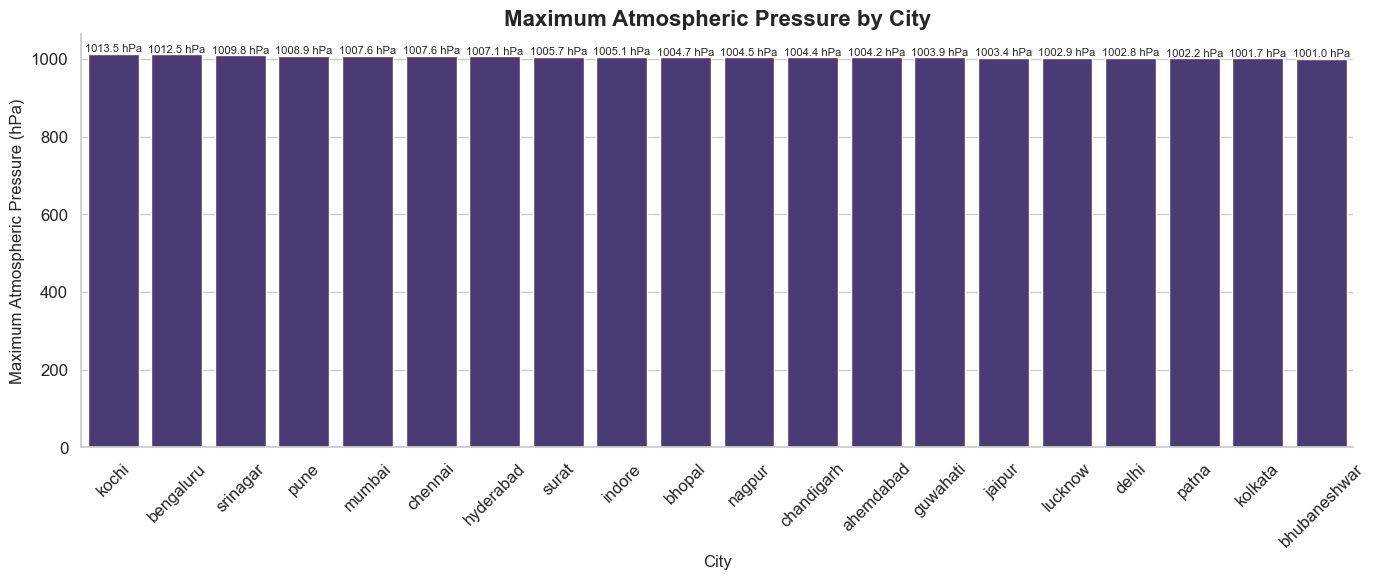

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    palette="viridis",
    font_scale=1.1
)

# Convert Series to DataFrame
atmpressure_df = max_atm_pressure_by_city.reset_index()

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=atmpressure_df,
    x="city",
    y="max_atm_pressure"
)

# Add value labels
ax.bar_label(
    ax.containers[0],
    fmt="%.1f hPa",
    padding=0,
    fontsize=8
)

plt.title(
    "Maximum Atmospheric Pressure by City",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("City", fontsize=12)
plt.ylabel("Maximum Atmospheric Pressure (hPa)", fontsize=12)

plt.xticks(rotation=45)

sns.despine()

plt.tight_layout()
plt.show()

### Insight

- **Kochi** recorded the **highest maximum atmospheric pressure** among the 20 cities, reaching **1013.5 hPa**, followed closely by **Bengaluru (1012.5 hPa)** and **Srinagar (1009.8 hPa)**.
- The **top five cities** with the highest maximum atmospheric pressure were **Kochi, Bengaluru, Srinagar, Pune, and Mumbai**, all recording values above **1007 hPa**.
- **Bhubaneshwar** recorded the **lowest maximum atmospheric pressure** at **1001.0 hPa**, indicating comparatively lower pressure conditions during the forecast period.
- The overall pressure range across all cities was relatively narrow, with a difference of only **12.5 hPa** between the highest and lowest recorded values, suggesting fairly stable atmospheric conditions across the dataset.
- Atmospheric pressure values for all cities remained within the **typical sea-level pressure range (approximately 1000–1015 hPa)**, indicating the absence of extreme high- or low-pressure weather systems during the forecast period.

**6. Which city receives the most precipitation?**

In [13]:
max_precipitation_by_city = (cities_df.groupby("city")["precipitation"].max().sort_values(ascending=False).rename("max_precipitation"))
print(f"Highest Precipitation City: {max_precipitation_by_city.idxmax()}")
print(f"Highest Precipitation of {max_precipitation_by_city.idxmax()} is: {max_precipitation_by_city.max()} mm")
print(f"Top 5 Cities With Highest Precipitation are: {max_precipitation_by_city.head()}")

Highest Precipitation City: surat
Highest Precipitation of surat is: 15.0 mm
Top 5 Cities With Highest Precipitation are: city
surat           15.0
mumbai          12.2
indore          10.1
pune             9.6
bhubaneshwar     8.3
Name: max_precipitation, dtype: float64


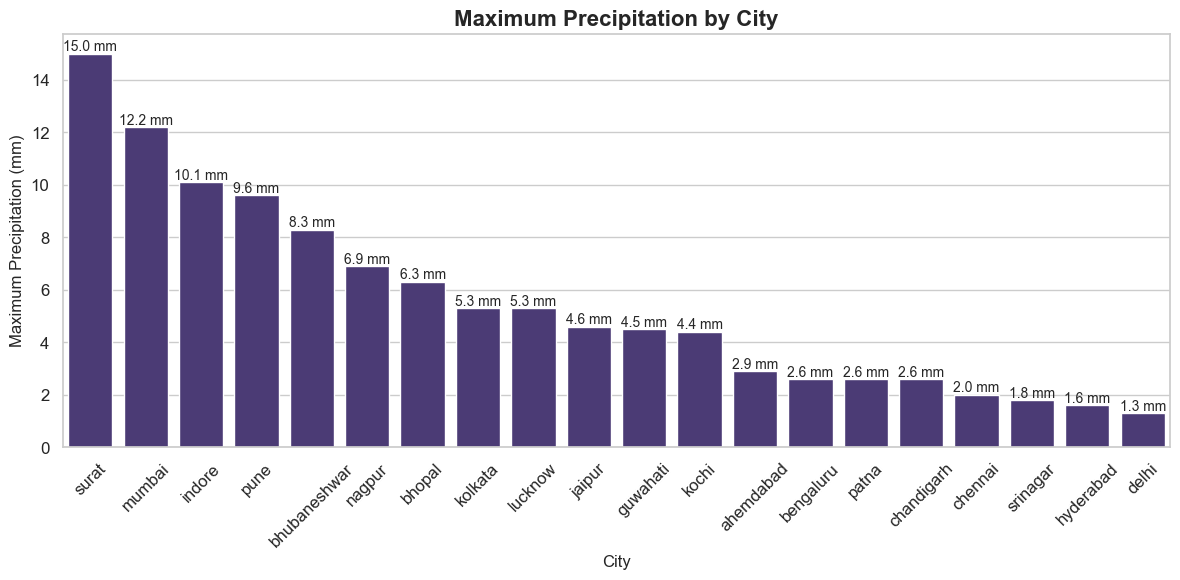

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    palette="viridis",
    font_scale=1.1
)

# Convert Series to DataFrame
max_precipitation_df = max_precipitation_by_city.reset_index()

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=max_precipitation_df,
    x="city",
    y="max_precipitation"
)

ax.bar_label(ax.containers[0], fmt='%.1f mm', padding=0, fontsize=10)

plt.title("Maximum Precipitation by City", fontsize=16, fontweight="bold")
plt.xlabel("City", fontsize=12)
plt.ylabel("Maximum Precipitation (mm)", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Insight

- **Surat** recorded the **highest maximum precipitation** among the 20 cities, reaching **15.0 mm**, indicating the most intense rainfall event during the forecast period.
- The **top five cities** with the highest maximum precipitation were **Surat (15.0 mm)**, **Mumbai (12.2 mm)**, **Indore (10.1 mm)**, **Pune (9.6 mm)**, and **Bhubaneshwar (8.3 mm)**, suggesting relatively wetter conditions in these locations.
- **Delhi** experienced the **lowest maximum precipitation** at **1.3 mm**, followed by **Hyderabad (1.6 mm)** and **Srinagar (1.8 mm)**, indicating comparatively drier weather during the forecast period.
- The difference between the highest and lowest maximum precipitation was **13.7 mm**, highlighting substantial regional variation in rainfall intensity across the selected Indian cities.
- The observed precipitation patterns suggest that some cities experienced significantly heavier rainfall events than others, which could influence urban drainage, transportation, and outdoor activities during the forecast period.

**7. How does temperature change throughout the day (Hourly)?**

In [16]:
hourly_temp = (cities_df.groupby("hour")["temperature_2m"].mean().sort_values(ascending=False).rename("avg_temperature"))
# print(f"Top 5 Cities With Highest Precipitation are: {hourly_temp.head()}")
hourly_temp.head()

hour
14    30.475714
13    30.470000
12    30.243571
15    30.115000
11    29.844286
Name: avg_temperature, dtype: float64

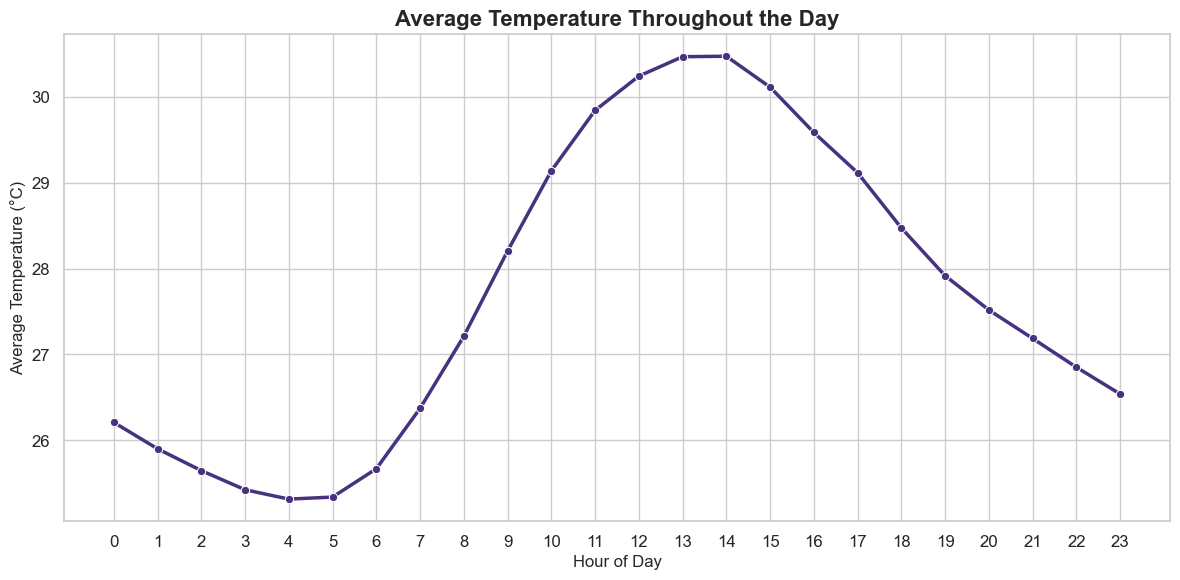

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    palette="viridis",
    font_scale=1.1
)

avg_temp_df = hourly_temp.reset_index()

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=avg_temp_df,
    x="hour",
    y="avg_temperature",
    marker="o",
    linewidth=2.5
)

plt.title("Average Temperature Throughout the Day", fontsize=16, fontweight="bold")
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Average Temperature (°C)", fontsize=12)

plt.xticks(range(24))

plt.tight_layout()
plt.show()

### Insight

- The **lowest average temperatures** were observed during the **early morning hours (04:00–05:00)**, reaching approximately **25.3°C**, making this the coolest period of the day.
- After **06:00**, temperatures increased steadily, with the most rapid warming occurring between **08:00 and 11:00**, indicating the transition from morning to midday heating.
- The **highest average temperature** of approximately **30.5°C** was recorded between **13:00 and 14:00**, representing the warmest part of the day across all 20 cities.
- Following the afternoon peak, temperatures gradually declined throughout the evening and night, returning to around **26.5°C** by **23:00**.
- The overall daily temperature variation was approximately **5.2°C**, demonstrating a consistent diurnal temperature cycle across the analyzed cities. This pattern aligns with typical weather behavior, where solar radiation drives daytime warming and temperatures decrease after sunset.

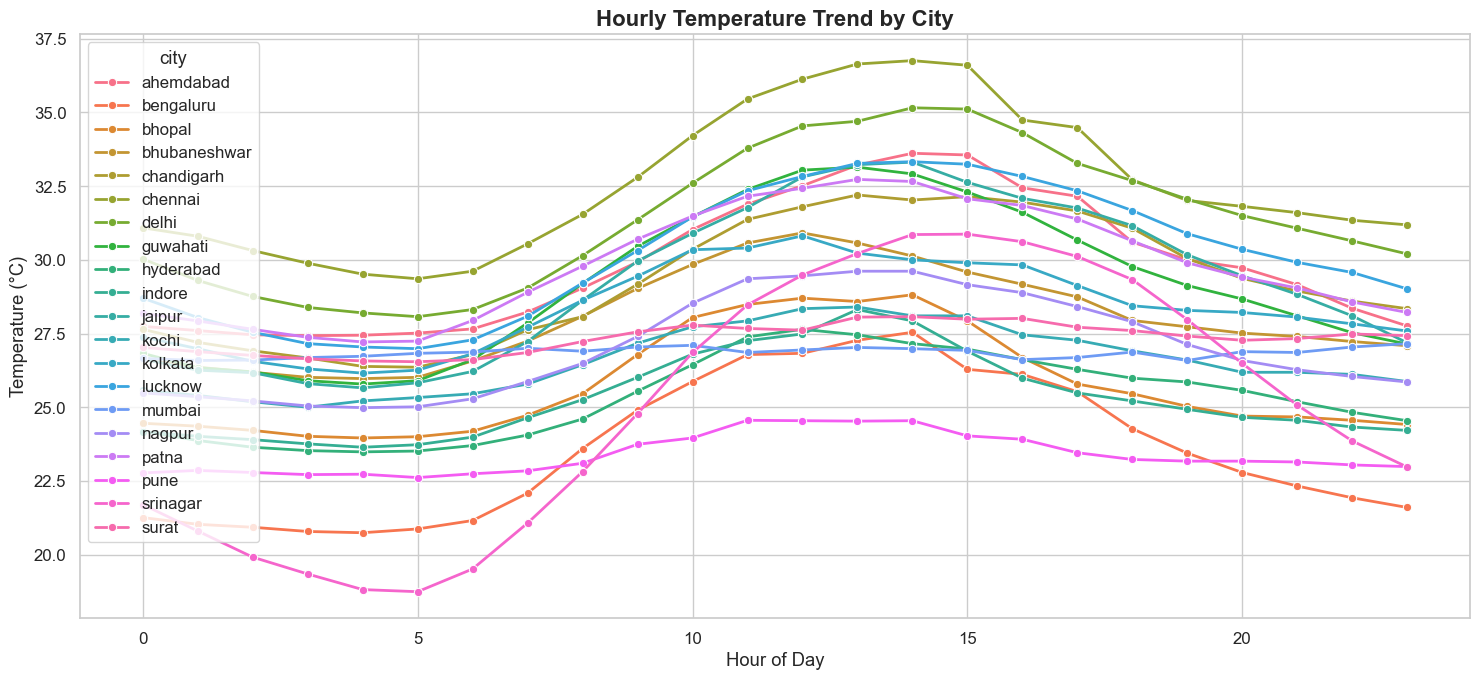

In [18]:
hourly_city_temp = (
    cities_df.groupby(["hour", "city"])["temperature_2m"]
             .mean()
             .reset_index()
)

plt.figure(figsize=(15, 7))

sns.lineplot(
    data=hourly_city_temp,
    x="hour",
    y="temperature_2m",
    hue="city",
    marker="o",
    linewidth=2
)

plt.title("Hourly Temperature Trend by City", fontsize=16, fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Temperature (°C)")

plt.tight_layout()
plt.show()

### Insight

- All cities exhibited a **consistent diurnal temperature pattern**, with temperatures reaching their **lowest levels during the early morning hours (04:00–06:00)**, increasing steadily after sunrise, peaking in the **early afternoon (13:00–15:00)**, and gradually declining during the evening.
- **Chennai** consistently recorded the **highest temperatures throughout the day**, peaking at approximately **36.7°C**, while **Bengaluru** maintained comparatively cooler temperatures, with its afternoon peak remaining below **29°C**.
- The greatest rate of warming across most cities occurred between **08:00 and 11:00**, reflecting the effect of increasing solar radiation during the morning hours.
- Despite differences in absolute temperature, nearly all cities followed a **similar hourly trend**, indicating that daily solar heating and nighttime cooling were the dominant factors influencing temperature variations across the dataset.
- Inland cities such as **Delhi, Lucknow, and Ahmedabad** experienced larger daytime temperature increases, whereas cities with relatively moderate profiles, such as **Bengaluru** and **Pune**, exhibited smaller daily fluctuations.
- The chart demonstrates that while each city has its own climatic characteristics, the **overall daily temperature cycle remains remarkably consistent**, with peak temperatures occurring during the afternoon and the coolest conditions observed just before sunrise.

**8. Compare Weekend vs Weekday**

Compare:
1. Temperature
2. Humidity
3. Cloud Cover

In [20]:
'''Aggregating all three variables'''

weekend_comparison = (
    cities_df.groupby("is_weekend")
    .agg(
        avg_temperature = ("temperature_2m", "mean"),
        avg_humidity = ("relative_humidity_2m", "mean"),
        avg_cloud_cover = ("cloud_cover", "mean")
    )
    .reset_index()
) 

weekend_comparison

,is_weekend,avg_temperature,avg_humidity,avg_cloud_cover
0,False,27.640083,81.605417,87.436250
1,True,27.841875,81.569792,85.080208


In [21]:
weekend_comparison["is_weekend"] = (weekend_comparison["is_weekend"].map({False: "Weekday", True: "Weekend"}))
weekend_comparison

,is_weekend,avg_temperature,avg_humidity,avg_cloud_cover
0,Weekday,27.640083,81.605417,87.436250
1,Weekend,27.841875,81.569792,85.080208


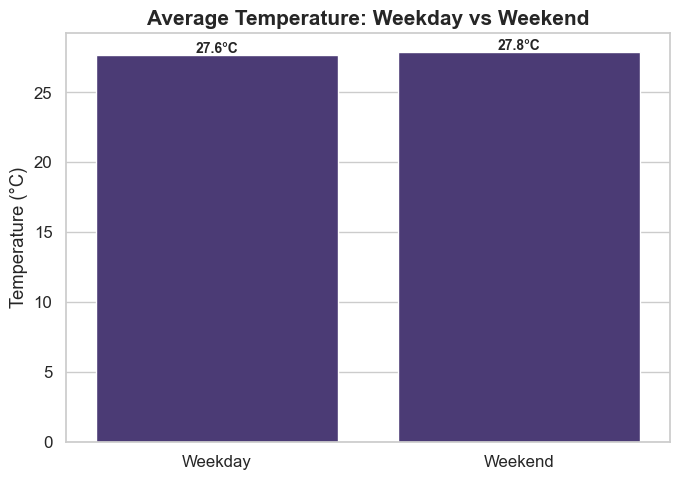

In [22]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=weekend_comparison,
    x="is_weekend",
    y="avg_temperature"
)

plt.title("Average Temperature: Weekday vs Weekend",
          fontsize=15,
          fontweight="bold")

ax.bar_label(ax.containers[0], fmt='%.1f°C', padding=0, fontsize=10, fontweight="bold")

plt.xlabel("")
plt.ylabel("Temperature (°C)")

plt.tight_layout()
plt.show()

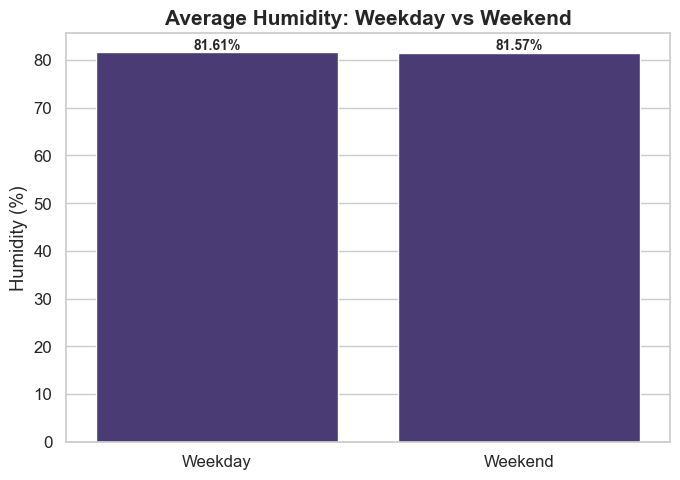

In [23]:
plt.figure(figsize=(7,5))

ax=sns.barplot(
    data=weekend_comparison,
    x="is_weekend",
    y="avg_humidity"
)

plt.title("Average Humidity: Weekday vs Weekend",
          fontsize=15,
          fontweight="bold")

# Add labels on top of bars
ax.bar_label(ax.containers[0], fmt='%.2f%%', padding=0, fontsize=10, fontweight="bold")

plt.xlabel("")
plt.ylabel("Humidity (%)")

plt.tight_layout()
plt.show()

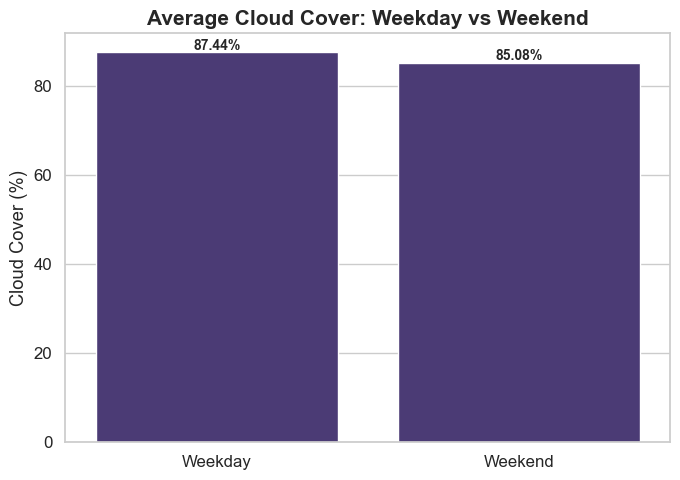

In [24]:
plt.figure(figsize=(7,5))

ax=sns.barplot(
    data=weekend_comparison,
    x="is_weekend",
    y="avg_cloud_cover"
)

plt.title("Average Cloud Cover: Weekday vs Weekend",
          fontsize=15,
          fontweight="bold")

ax.bar_label(ax.containers[0], fmt='%.2f%%', padding=0, fontsize=10, fontweight="bold")

plt.xlabel("")
plt.ylabel("Cloud Cover (%)")

plt.tight_layout()
plt.show()

### Insight

- The comparison between **weekdays and weekends** shows **minimal variation** in the selected weather metrics, indicating that day-of-week has little influence on weather conditions.
- The **average temperature** was slightly higher on **weekends (27.8°C)** compared to **weekdays (27.6°C)**, with a marginal difference of **0.2°C**.
- The **average humidity** remained almost identical throughout the week, measuring **81.61% on weekdays** and **81.57% on weekends**, suggesting consistently humid atmospheric conditions.
- **Average cloud cover** was also very similar, with **87.44% on weekdays** and **85.08% on weekends**, indicating persistently cloudy weather across the forecast period.
- Overall, the negligible differences across temperature, humidity, and cloud cover confirm that **weather patterns are independent of the weekday/weekend cycle**. The observed variations are too small to indicate any meaningful trend and are likely due to natural short-term weather fluctuations rather than the calendar.

**9. Distribution of temperatures**

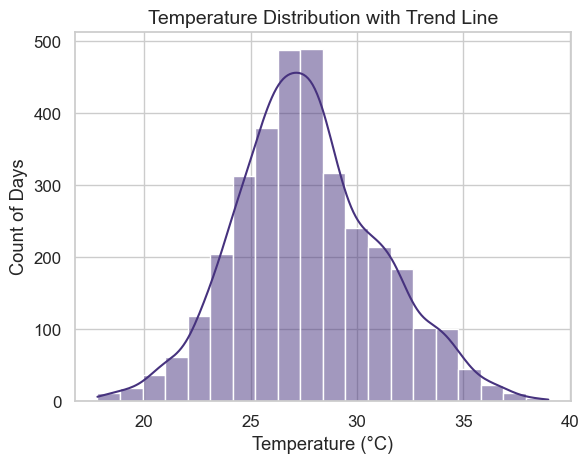

In [25]:
sns.histplot(data=cities_df, x='temperature_2m', bins=20, kde=True)
sns.set_theme(style="darkgrid")

plt.title('Temperature Distribution with Trend Line', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Count of Days')
plt.show()

### Insight

- The temperature distribution is **approximately bell-shaped**, with most observations concentrated between **24°C and 30°C**, indicating that moderate temperatures were the most common across the selected cities.
- The **highest frequency** of temperature observations occurs around **26–27°C**, suggesting this was the typical temperature range during the forecast period.
- Very **low (<20°C)** and **high (>35°C)** temperatures were relatively rare, as indicated by the sparse bars at both ends of the distribution.
- The distribution exhibits a **slight positive (right) skew**, with a longer tail extending toward higher temperatures. This indicates that while most temperatures remained moderate, a smaller number of observations experienced significantly warmer conditions.
- Overall, the distribution suggests that the weather across the analyzed cities was **generally warm and stable**, with only a limited number of extreme temperature events during the forecast period.

**10. Correlation Matrix**

Variables:

1. Temperature
2. Humidity
3. Pressure
4. Wind
5. Cloud Cover
6. Rainfall

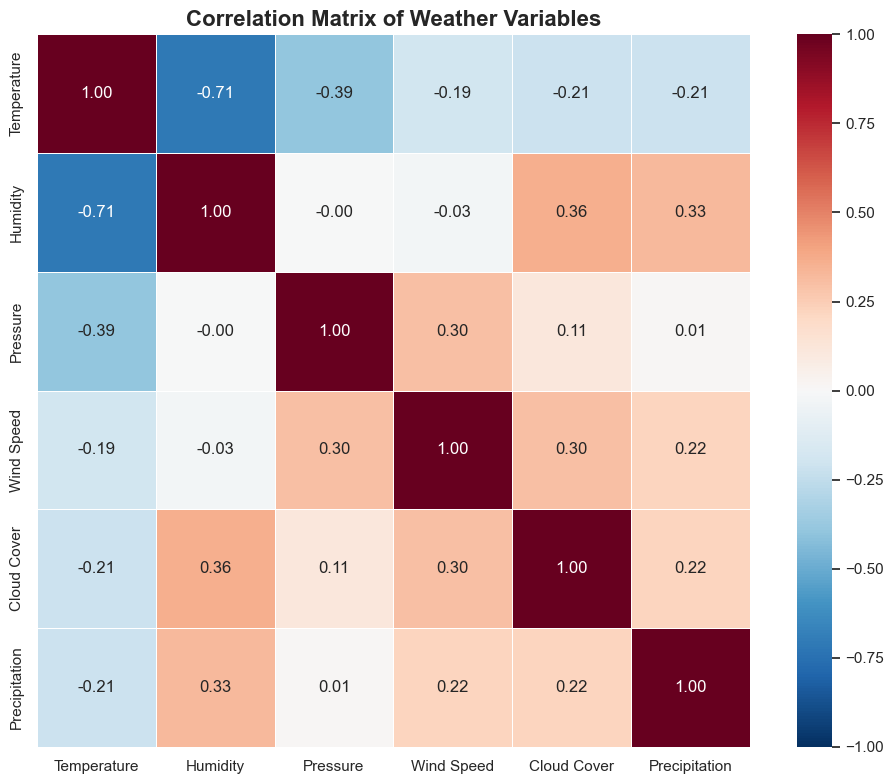

In [26]:
corr_df = cities_df[
    [
        "temperature_2m",
        "relative_humidity_2m",
        "pressure_msl",
        "wind_speed_10m",
        "cloud_cover",
        "precipitation",
    ]
].rename(
    columns={
        "temperature_2m": "Temperature",
        "relative_humidity_2m": "Humidity",
        "pressure_msl": "Pressure",
        "wind_speed_10m": "Wind Speed",
        "cloud_cover": "Cloud Cover",
        "precipitation": "Precipitation",
    }
)

corr_matrix = corr_df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Matrix of Weather Variables",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Insight

- **Temperature and Humidity** exhibited a **strong negative correlation (-0.71)**, indicating that higher temperatures were generally associated with lower relative humidity across the analyzed cities.
- **Pressure and Wind Speed** showed a **moderate positive correlation (0.30)**, suggesting that periods of higher atmospheric pressure were often accompanied by slightly stronger winds.
- **Humidity** demonstrated a **moderate positive correlation** with both **Cloud Cover (0.36)** and **Precipitation (0.33)**, indicating that more humid conditions were generally associated with increased cloudiness and rainfall.
- **Cloud Cover** and **Wind Speed** also showed a **moderate positive relationship (0.30)**, suggesting that cloudier conditions tended to coincide with moderately higher wind speeds.
- **Temperature** displayed **weak negative correlations** with **Pressure (-0.39)**, **Wind Speed (-0.19)**, **Cloud Cover (-0.21)**, and **Precipitation (-0.21)**, implying that warmer conditions were slightly associated with lower pressure, reduced cloud cover, and lower rainfall.
- Overall, the correlation analysis indicates that **temperature and humidity have the strongest inverse relationship**, while most other weather variables exhibit **weak to moderate linear associations**, suggesting that multiple atmospheric factors jointly influence weather conditions rather than any single variable acting independently.

**11. Most frequent weather condition**

In [27]:
weather_code_count = (
    cities_df["weather_code"]
    .value_counts()
    .sort_index()
    .rename("count")
    .reset_index()
)

weather_code_count.columns = ["weather_code", "count"]

weather_code_count

,weather_code,count
0,0,134
1,1,134
2,2,155
3,3,803
4,51,791
5,53,266
6,55,66
7,61,7
8,63,5
9,80,82


In [28]:
print(f"Most Frequent Weather Code: {weather_code_count.loc[0, 'weather_code']}")
print(f"Occurrences: {weather_code_count.loc[0, 'count']}")

Most Frequent Weather Code: 0
Occurrences: 134


In [29]:
'''Mapping weather_codes based on the Open-Meteo Weather Interpretation Codes'''

weather_map = {
    0: "Clear Sky",
    1: "Mainly Clear",
    2: "Partly Cloudy",
    3: "Overcast",
    45: "Fog",
    48: "Depositing Rime Fog",
    51: "Light Drizzle",
    53: "Moderate Drizzle",
    55: "Dense Drizzle",
    56: "Freezing Drizzle",
    57: "Dense Freezing Drizzle",
    61: "Slight Rain",
    63: "Moderate Rain",
    65: "Heavy Rain",
    66: "Freezing Rain",
    67: "Heavy Freezing Rain",
    71: "Slight Snow",
    73: "Moderate Snow",
    75: "Heavy Snow",
    77: "Snow Grains",
    80: "Rain Showers",
    81: "Heavy Rain Showers",
    82: "Violent Rain Showers",
    85: "Snow Showers",
    86: "Heavy Snow Showers",
    95: "Thunderstorm",
    96: "Thunderstorm with Hail",
    99: "Severe Thunderstorm"
}

weather_code_count["condition"] = weather_code_count["weather_code"].map(weather_map)

weather_code_count

,weather_code,count,condition
0,0,134,Clear Sky
1,1,134,Mainly Clear
2,2,155,Partly Cloudy
3,3,803,Overcast
4,51,791,Light Drizzle
5,53,266,Moderate Drizzle
6,55,66,Dense Drizzle
7,61,7,Slight Rain
8,63,5,Moderate Rain
9,80,82,Rain Showers


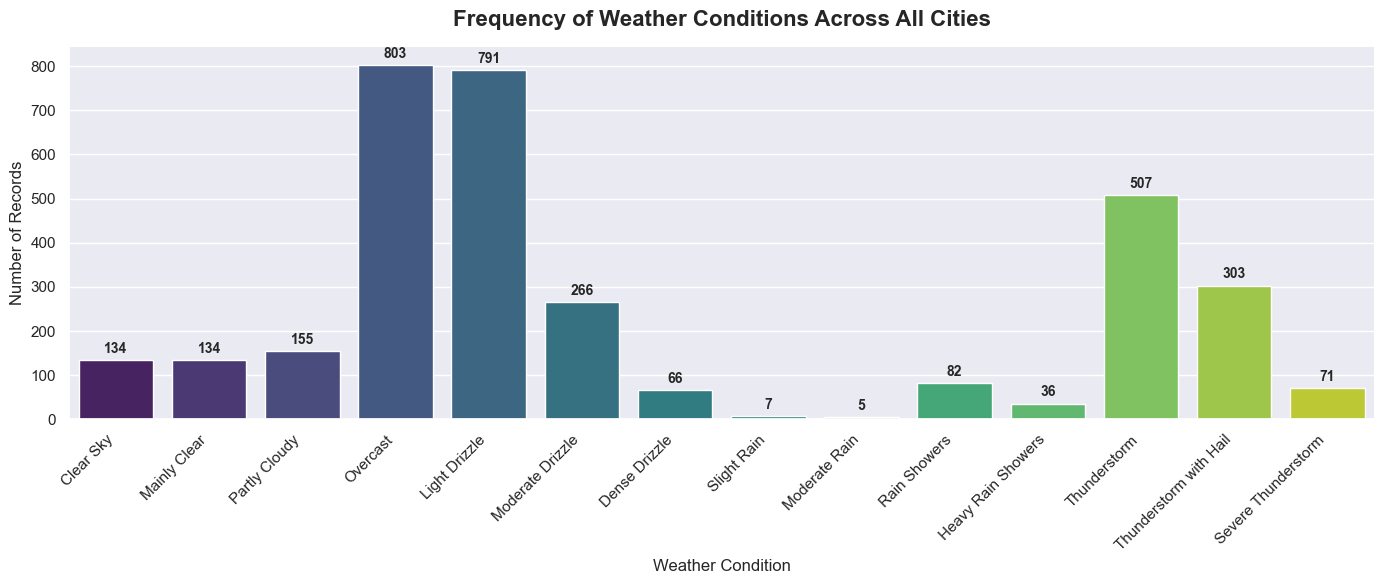

In [30]:
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=weather_code_count,
    x="condition",
    y="count",
    hue="condition",
    palette="viridis",
    legend=False
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3,
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Frequency of Weather Conditions Across All Cities",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Weather Condition", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)

plt.xticks(rotation=45, ha="right")

# Remove unnecessary borders
sns.despine()

plt.tight_layout()
plt.show()

### Insight

- **Overcast** was the **most frequently observed weather condition**, with **803 occurrences**, closely followed by **Light Drizzle (791 occurrences)**. This indicates that cloudy and light rainfall conditions dominated the forecast period across the selected cities.
- **Thunderstorms** were also relatively common, occurring **507 times**, while **Thunderstorms with Hail** were recorded **303 times**, suggesting that convective weather events were significant during the observation period.
- Moderate weather conditions such as **Moderate Drizzle (266 occurrences)**, **Partly Cloudy (155 occurrences)**, **Clear Sky (134 occurrences)**, and **Mainly Clear (134 occurrences)** occurred less frequently than overcast and drizzle conditions.
- Heavy rainfall events were comparatively uncommon. **Rain Showers (82 occurrences)**, **Severe Thunderstorms (71 occurrences)**, **Dense Drizzle (66 occurrences)**, and **Heavy Rain Showers (36 occurrences)** were observed only occasionally.
- **Moderate Rain (5 occurrences)** and **Slight Rain (7 occurrences)** were the **least frequently recorded weather conditions**, indicating that rainfall during the forecast period was more commonly classified as drizzle or thunderstorms rather than continuous rainfall.
- Overall, the weather pattern across the analyzed cities was characterized by **predominantly cloudy skies, frequent light drizzle, and occasional thunderstorm activity**, while prolonged rainfall events remained relatively rare.

**12. Which city has the greatest temperature variation?**

In [31]:
temp_variation = (
    cities_df.groupby("city")["temperature_2m"]
    .std()
    .rename("temperature_variation")
    .sort_values(ascending=False)
)

temp_variation

city
srinagar        4.547644
jaipur          2.991510
delhi           2.827975
guwahati        2.767627
chennai         2.718179
bengaluru       2.533558
ahemdabad       2.509724
lucknow         2.402333
chandigarh      2.337165
patna           2.186158
bhubaneshwar    2.099248
bhopal          2.034964
nagpur          2.020616
hyderabad       1.946140
indore          1.764927
kolkata         1.722871
kochi           1.548941
surat           0.967800
mumbai          0.954973
pune            0.946682
Name: temperature_variation, dtype: float64

In [32]:
print(f"City with Greatest Temperature Variation: {temp_variation.idxmax()}")
print(f"Temperature Variation: {temp_variation.max():.2f} °C")

print("\nTop 5 Cities with Greatest Temperature Variation:")
print(temp_variation.head())

temp_variation_df = temp_variation.reset_index()

City with Greatest Temperature Variation: srinagar
Temperature Variation: 4.55 °C

Top 5 Cities with Greatest Temperature Variation:
city
srinagar    4.547644
jaipur      2.991510
delhi       2.827975
guwahati    2.767627
chennai     2.718179
Name: temperature_variation, dtype: float64


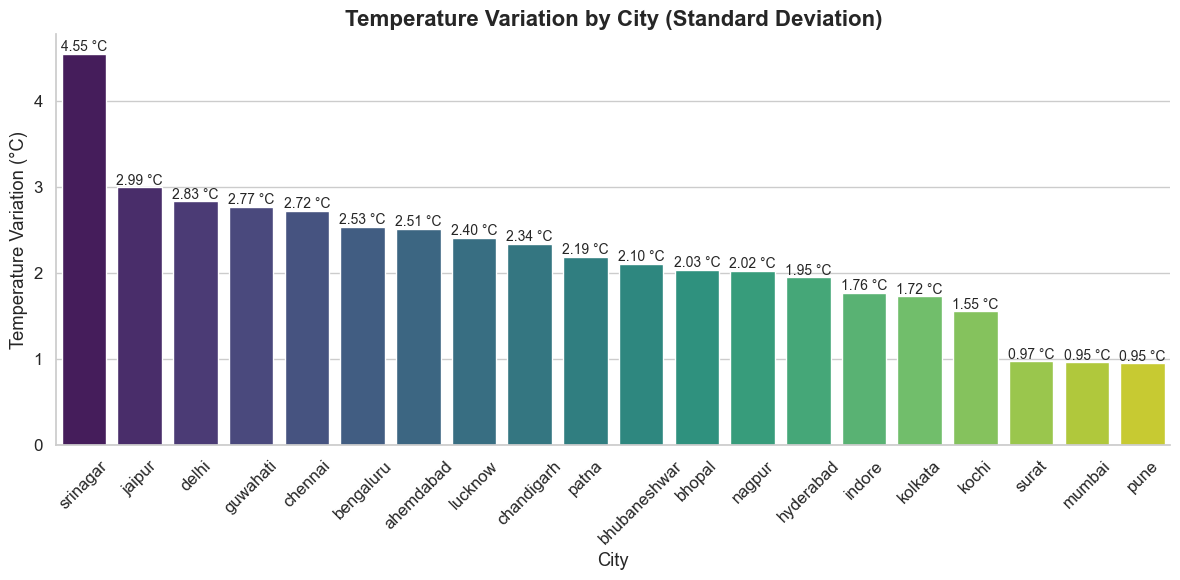

In [54]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=temp_variation_df,
    x="city",
    y="temperature_variation",
    hue="city",
    palette="viridis",
    legend=False
)

# Value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f °C",
        padding=0,
        fontsize=10
    )

plt.title(
    "Temperature Variation by City (Standard Deviation)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("City")
plt.ylabel("Temperature Variation (°C)")
plt.xticks(rotation=45)

sns.despine()

plt.tight_layout()
plt.show()

### Insight

- **Srinagar** exhibited the **greatest temperature variation**, with a standard deviation of **4.55°C**, indicating the most fluctuating temperature pattern among the analyzed cities.
- **Jaipur (2.99°C)**, **Delhi (2.83°C)**, **Guwahati (2.77°C)**, and **Chennai (2.72°C)** also experienced relatively high temperature variability, reflecting more pronounced daily temperature fluctuations.
- In contrast, **Mumbai (0.95°C)** and **Pune (0.95°C)** recorded the **lowest temperature variation**, followed closely by **Surat (0.97°C)**, indicating consistently stable temperatures throughout the forecast period.
- The difference between the highest and lowest temperature variation was **3.60°C**, demonstrating significant differences in temperature stability across the selected cities.
- Cities with **higher temperature variation** are more likely to experience noticeable warming during the day and cooling at night, whereas cities with **lower variation** maintain relatively consistent temperatures. This pattern is influenced by factors such as geography, elevation, proximity to large water bodies, and prevailing local weather conditions.